# 🛺 Dilli Electric Auto — EV Market Intelligence (2025)
### Exploratory Data Analysis | VAHAN Registration Data | 11 States | 611 Makers

**Business Context:**  
Dilli Electric Auto is an e-rickshaw and loader manufacturer operating across North and East India.  
This analysis uses VAHAN (Government of India) registration data to map the competitive landscape,  
identify DEA's market position, and surface strategic growth opportunities.

**Data Source:** [VAHAN Dashboard](https://vahan.parivahan.gov.in/vahan4dashboard) — 2025  
**Scope:** 11 States | 12 Months | 869,751 Total Registrations

---


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('/home/claude/dilli_ev_project/outputs', exist_ok=True)
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

MONTH_ORDER = ['JAN','FEB','MAR','APR','MAY','JUN',
               'JUL','AUG','SEP','OCT','NOV','DEC']

df = pd.read_csv('/home/claude/dilli_ev_project/data/market_clean.csv')
df['Month'] = pd.Categorical(df['Month'], categories=MONTH_ORDER, ordered=True)
print(f"Rows       : {df.shape[0]:,}")
print(f"Columns    : {df.shape[1]}")
print(f"Makers     : {df['Maker'].nunique()}")
print(f"States     : {df['State'].nunique()}")
print(f"Total Regs : {df['Registerations'].sum():,}")
df.head()


Rows       : 25,332
Columns    : 8
Makers     : 611
States     : 11
Total Regs : 869,751


,Maker,Maker_Group,Month,Registerations,State,Month_Num,Is_DEA,Annual_Total
0,3S INDUSTRIES PRIVATE LIMITED,Others,JAN,18,Bihar,1,0,262
1,3S INDUSTRIES PRIVATE LIMITED,Others,FEB,19,Bihar,2,0,262
2,3S INDUSTRIES PRIVATE LIMITED,Others,MAR,13,Bihar,3,0,262
3,3S INDUSTRIES PRIVATE LIMITED,Others,APR,26,Bihar,4,0,262
4,3S INDUSTRIES PRIVATE LIMITED,Others,MAY,24,Bihar,5,0,262


## 2. Data Overview

In [2]:
# Data types and nulls
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Null Values ===")
print(df.isnull().sum())
print()
print("=== Basic Stats ===")
df['Registerations'].describe().to_frame()


=== Data Types ===
Maker                  str
Maker_Group            str
Month             category
Registerations       int64
State                  str
Month_Num            int64
Is_DEA               int64
Annual_Total         int64
dtype: object

=== Null Values ===
Maker             0
Maker_Group       0
Month             0
Registerations    0
State             0
Month_Num         0
Is_DEA            0
Annual_Total      0
dtype: int64

=== Basic Stats ===


,Registerations
count,25332.000000
mean,34.334083
std,204.411598
min,0.000000
25%,0.000000
50%,2.000000
75%,14.000000
max,7427.000000


In [3]:
# Sample of key columns
df[['Maker','Maker_Group','State','Month','Registerations']].sample(10, random_state=42)


,Maker,Maker_Group,State,Month,Registerations
323,ASHMA-MOTORS PVT LTD,Others,Bihar,DEC,9
19517,CHAMPION POLY PLAST,Others,UP,JUN,248
5764,NEW ARCANA INDIA,Others,Delhi,MAY,20
21738,OMEGA SALES & AGRO INDUSTRIES,Others,UP,JUL,9
21189,LIMO AUTO CARE PVT LTD,Others,UP,OCT,7
5035,CART INDIA,Others,Delhi,AUG,10
15420,M/S SHRIRAM AUTO TECH PVT LTD,Others,Punjab,JAN,0
6165,TWO FRIENDS AUTO ELECTRIC PVT LTD,Others,Delhi,OCT,37
13431,OMEGA SALES & AGRO INDUSTRIES,Others,MP,APR,0
15213,KUKU AUTOMOTIVES,Others,Punjab,OCT,1


## 3. Market Share Analysis
**Question:** Who dominates the EV 3-Wheeler market in India?


In [4]:
group_share = (df.groupby('Maker_Group')['Registerations']
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index())
group_share['Market_Share_%'] = (group_share['Registerations'] / group_share['Registerations'].sum() * 100).round(2)
group_share


,Maker_Group,Registerations,Market_Share_%
0,Others,706914,81.28
1,Mahindra,71262,8.19
2,YC,38184,4.39
3,Saera Electric,23449,2.70
4,Dilli Electric Auto,20065,2.31
5,Zeniak,9877,1.14


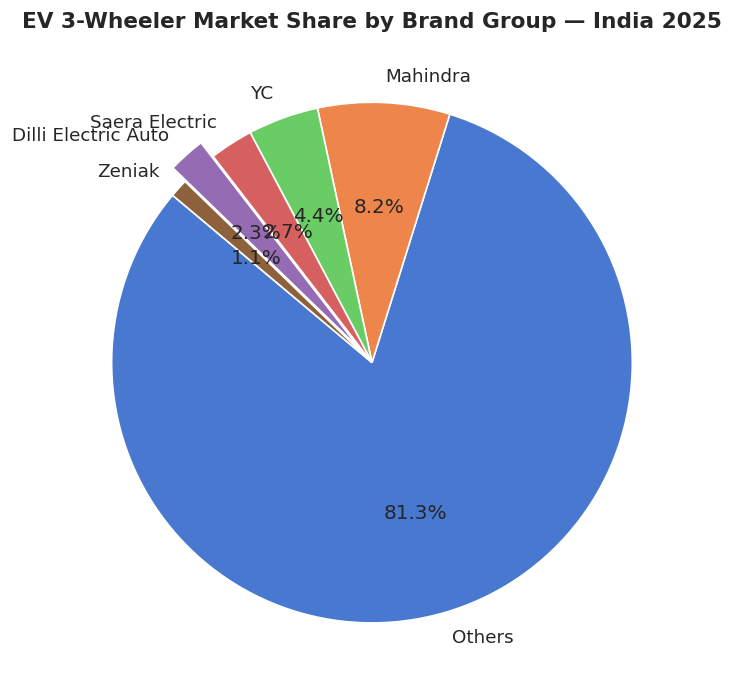

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
explode = [0.07 if g == 'Dilli Electric Auto' else 0 for g in group_share['Maker_Group']]
ax.pie(
    group_share['Registerations'],
    labels=group_share['Maker_Group'],
    autopct='%1.1f%%',
    explode=explode,
    startangle=140
)
ax.set_title('EV 3-Wheeler Market Share by Brand Group — India 2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/dilli_ev_project/outputs/plot1_market_share_pie.png')
plt.show()


## 4. Top 10 Competitors
**Question:** Who are DEA's biggest direct competitors nationally?


In [6]:
top10 = (df.groupby(['Maker','Maker_Group'])['Registerations']
           .sum()
           .sort_values(ascending=False)
           .head(10)
           .reset_index())
top10


,Maker,Maker_Group,Registerations
0,BAJAJ AUTO LTD,Others,224736
1,MAHINDRA LAST MILE MOBILITY LTD,Mahindra,70633
2,YC ELECTRIC VEHICLE,YC,36871
3,PIAGGIO VEHICLES PVT LTD,Others,34715
4,TVS MOTOR COMPANY LTD,Others,24534
5,SAERA ELECTRIC AUTO PVT LTD,Saera Electric,23449
6,DILLI ELECTRIC AUTO PVT LTD,Dilli Electric Auto,20065
7,MINI METRO EV L.L.P,Others,12805
8,ENERGY ELECTRIC VEHICLES,Others,12621
9,ATUL AUTO LTD,Others,11560


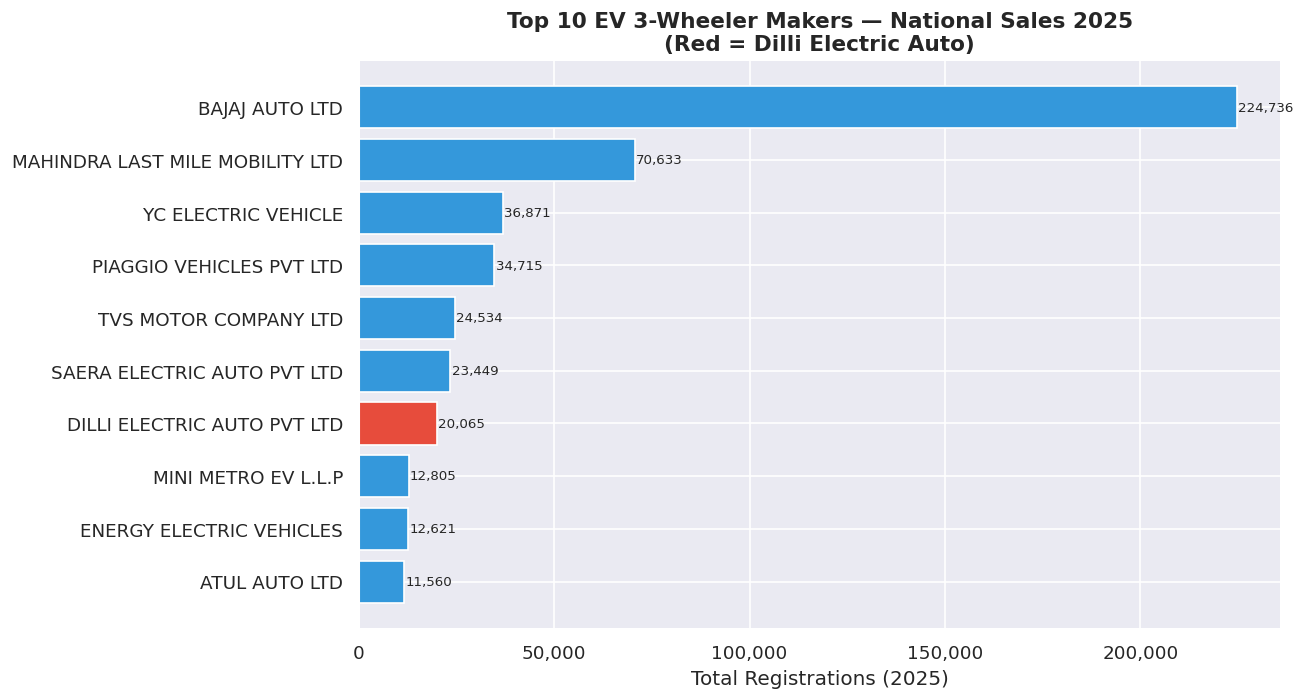

In [7]:
colors = ['#e74c3c' if 'DILLI' in m else '#3498db' for m in top10['Maker']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10['Maker'][::-1], top10['Registerations'][::-1], color=colors[::-1])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Total Registrations (2025)')
ax.set_title('Top 10 EV 3-Wheeler Makers — National Sales 2025\n(Red = Dilli Electric Auto)', 
             fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('/home/claude/dilli_ev_project/outputs/plot2_top10_makers.png')
plt.show()


## 5. Monthly Sales Trend
**Question:** Is DEA growing month-over-month? How does it compare to Bajaj?


In [8]:
monthly_industry = df.groupby('Month')['Registerations'].sum().reset_index()
monthly_dea      = (df[df['Maker_Group']=='Dilli Electric Auto']
                      .groupby('Month')['Registerations'].sum().reset_index())
monthly_bajaj    = (df[df['Maker']=='BAJAJ AUTO LTD']
                      .groupby('Month')['Registerations'].sum().reset_index())

# MoM growth for DEA
monthly_dea['MoM_Growth_%'] = monthly_dea['Registerations'].pct_change().mul(100).round(2)
print("DEA Month-over-Month Growth:")
monthly_dea[['Month','Registerations','MoM_Growth_%']]


DEA Month-over-Month Growth:


,Month,Registerations,MoM_Growth_%
0,JAN,1774,NaN
1,FEB,1584,-10.71
2,MAR,1552,-2.02
3,APR,1653,6.51
4,MAY,1582,-4.30
5,JUN,1539,-2.72
6,JUL,1747,13.52
7,AUG,1662,-4.87
8,SEP,1372,-17.45
9,OCT,1683,22.67


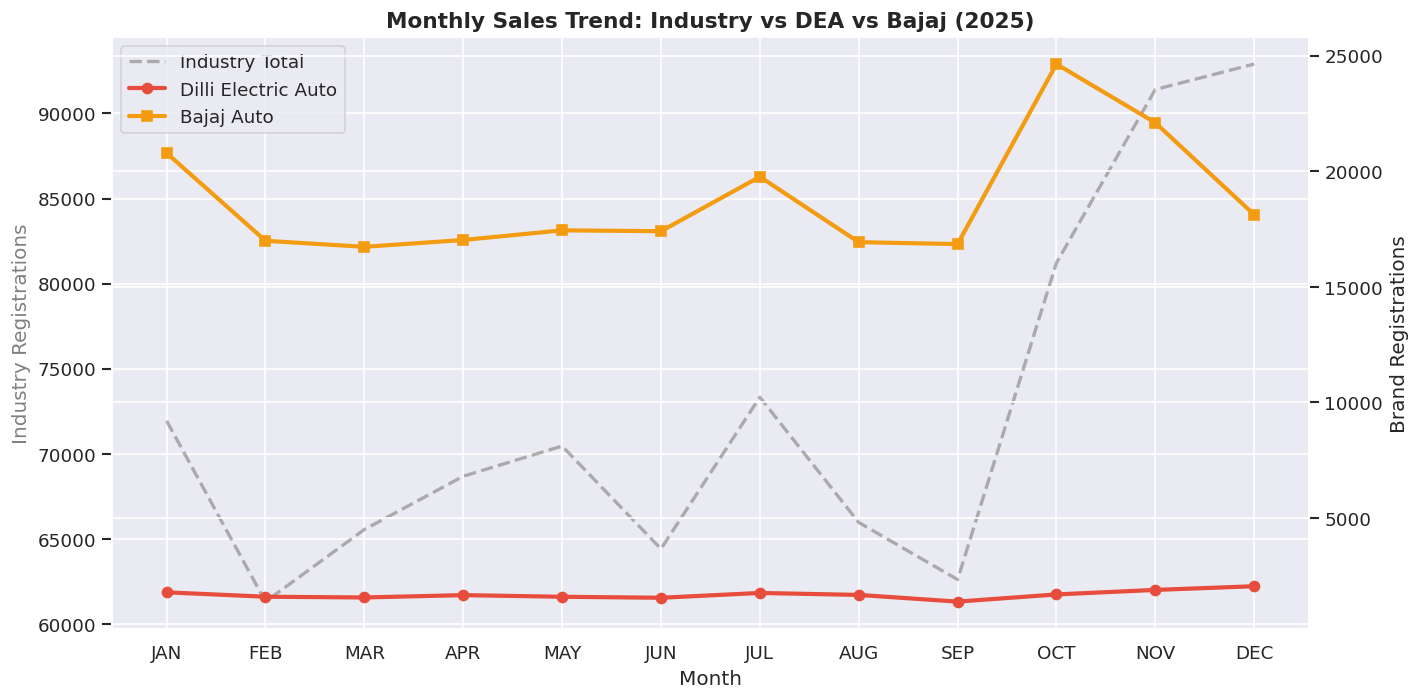

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(monthly_industry['Month'], monthly_industry['Registerations'],
         color='grey', linewidth=2, linestyle='--', label='Industry Total', alpha=0.6)
ax2.plot(monthly_dea['Month'], monthly_dea['Registerations'],
         color='#e74c3c', linewidth=2.5, marker='o', label='Dilli Electric Auto')
ax2.plot(monthly_bajaj['Month'], monthly_bajaj['Registerations'],
         color='#f39c12', linewidth=2.5, marker='s', label='Bajaj Auto')

ax1.set_ylabel('Industry Registrations', color='grey')
ax2.set_ylabel('Brand Registrations')
ax1.set_xlabel('Month')
ax1.set_title('Monthly Sales Trend: Industry vs DEA vs Bajaj (2025)', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/home/claude/dilli_ev_project/outputs/plot3_monthly_trend.png')
plt.show()


## 6. State-wise Performance
**Question:** Where is DEA strong? Where is the untapped opportunity?


In [10]:
state_total = df.groupby('State')['Registerations'].sum().reset_index()
state_total.columns = ['State','Market_Size']

dea_state = (df[df['Maker_Group']=='Dilli Electric Auto']
               .groupby('State')['Registerations'].sum().reset_index())
dea_state.columns = ['State','DEA_Units']

state_df = state_total.merge(dea_state, on='State', how='left').fillna(0)
state_df['DEA_Share_%'] = (state_df['DEA_Units'] / state_df['Market_Size'] * 100).round(2)
state_df['Opportunity'] = state_df.apply(
    lambda r: 'HIGH' if r['Market_Size'] > 50000 and r['DEA_Share_%'] < 3
    else ('MEDIUM' if r['Market_Size'] > 20000 and r['DEA_Share_%'] < 5 else 'Stable'), axis=1
)
state_df.sort_values('Market_Size', ascending=False)


,State,Market_Size,DEA_Units,DEA_Share_%,Opportunity
9,UP,309300,6782,2.19,HIGH
0,Bihar,119631,3255,2.72,HIGH
6,Maharasthra,94500,1093,1.16,HIGH
10,West Bengal,79819,753,0.94,HIGH
2,Delhi,67729,2319,3.42,MEDIUM
5,MP,55279,2204,3.99,MEDIUM
8,Rajasthan,44229,503,1.14,MEDIUM
4,Jharkhand,33493,192,0.57,MEDIUM
3,Haryana,32849,2349,7.15,Stable
7,Punjab,17052,386,2.26,Stable


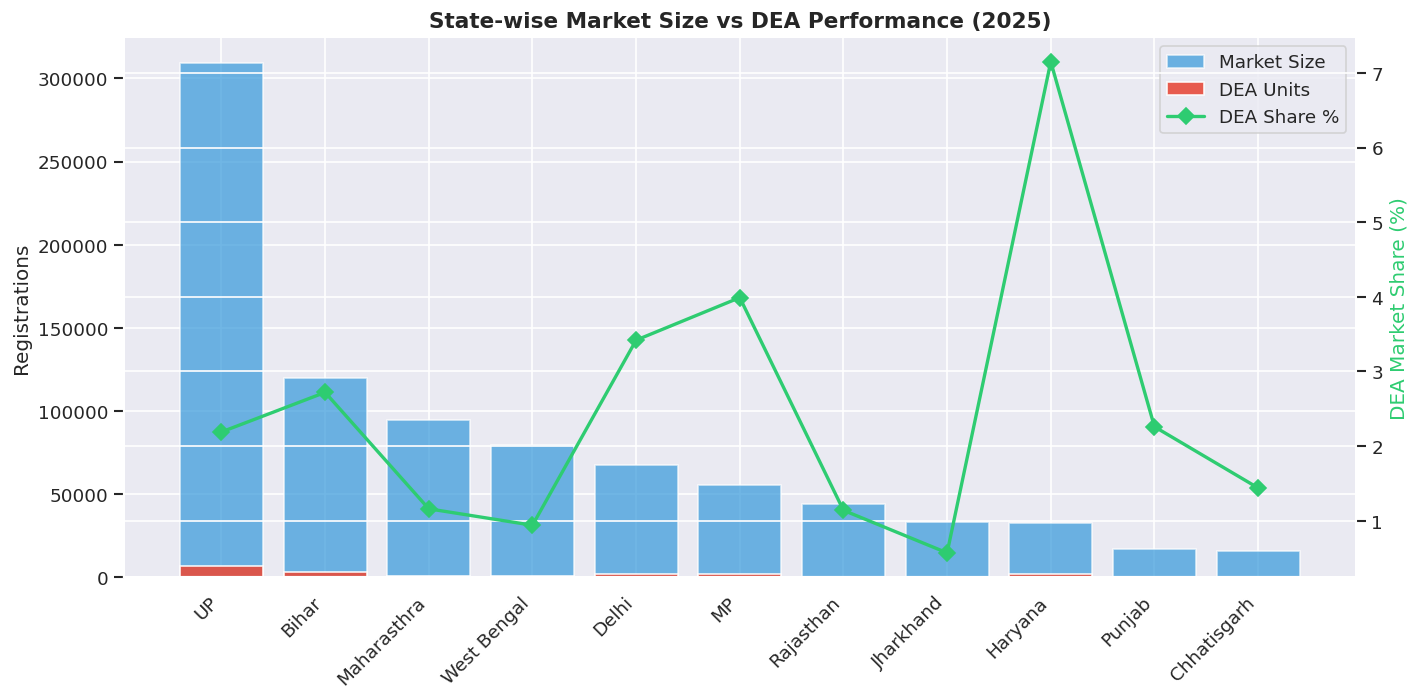

In [11]:
state_df_sorted = state_df.sort_values('Market_Size', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
x = range(len(state_df_sorted))

ax1.bar(x, state_df_sorted['Market_Size'], color='#3498db', alpha=0.7, label='Market Size')
ax1.bar(x, state_df_sorted['DEA_Units'],   color='#e74c3c', alpha=0.9, label='DEA Units')
ax2.plot(x, state_df_sorted['DEA_Share_%'], color='#2ecc71', marker='D',
         linewidth=2, markersize=7, label='DEA Share %')

ax1.set_xticks(x)
ax1.set_xticklabels(state_df_sorted['State'], rotation=45, ha='right')
ax1.set_ylabel('Registrations')
ax2.set_ylabel('DEA Market Share (%)', color='#2ecc71')
ax1.set_title('State-wise Market Size vs DEA Performance (2025)', fontsize=13, fontweight='bold')
lines1, _ = ax1.get_legend_handles_labels()
lines2, _ = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, ['Market Size','DEA Units','DEA Share %'], loc='upper right')
plt.tight_layout()
plt.savefig('/home/claude/dilli_ev_project/outputs/plot4_state_dea_share.png')
plt.show()


## 7. DEA Sales Heatmap — State × Month
**Question:** When and where does DEA sell the most?


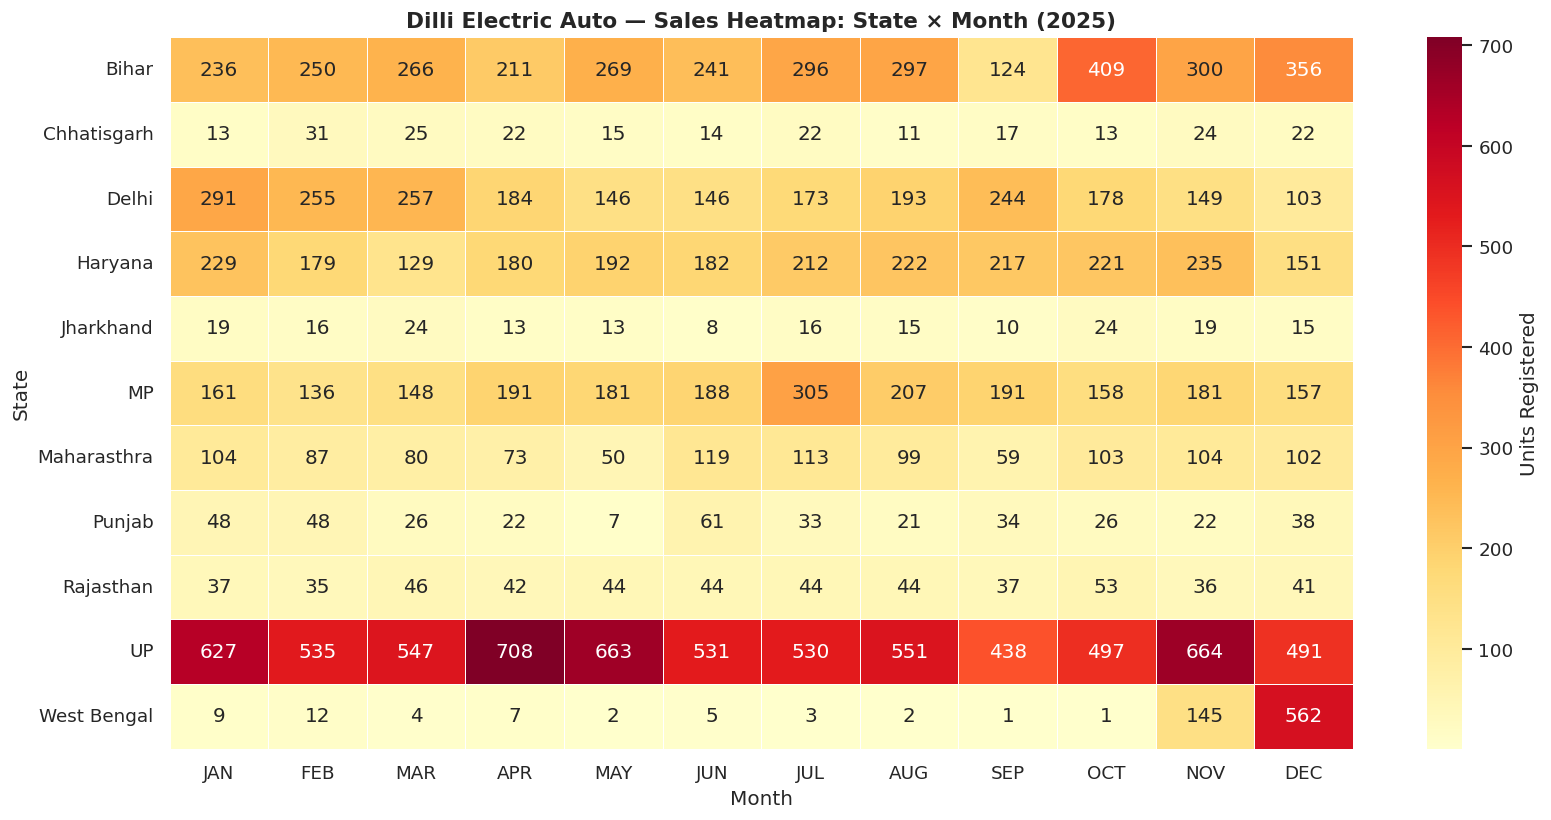

In [12]:
dea_pivot = (df[df['Maker_Group']=='Dilli Electric Auto']
               .groupby(['State','Month'])['Registerations']
               .sum()
               .unstack('Month')
               .reindex(columns=MONTH_ORDER)
               .fillna(0)
               .astype(int))

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(dea_pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Units Registered'})
ax.set_title('Dilli Electric Auto — Sales Heatmap: State × Month (2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/dilli_ev_project/outputs/plot5_dea_heatmap.png')
plt.show()


## 8. Pareto Analysis — 80/20 Rule
**Question:** How many makers drive 80% of the total market?


In [13]:
maker_totals = (df.groupby('Maker')['Registerations']
                  .sum()
                  .sort_values(ascending=False)
                  .reset_index())
maker_totals['Cumulative_%'] = (maker_totals['Registerations'].cumsum()
                                / maker_totals['Registerations'].sum() * 100).round(2)
top_80 = maker_totals[maker_totals['Cumulative_%'] <= 80]
print(f"Makers driving 80% of market : {len(top_80)} out of {len(maker_totals)}")
top_80.head(15)


Makers driving 80% of market : 55 out of 611


,Maker,Registerations,Cumulative_%
0,BAJAJ AUTO LTD,224736,25.84
1,MAHINDRA LAST MILE MOBILITY LTD,70633,33.96
2,YC ELECTRIC VEHICLE,36871,38.20
3,PIAGGIO VEHICLES PVT LTD,34715,42.19
4,TVS MOTOR COMPANY LTD,24534,45.01
5,SAERA ELECTRIC AUTO PVT LTD,23449,47.71
6,DILLI ELECTRIC AUTO PVT LTD,20065,50.01
7,MINI METRO EV L.L.P,12805,51.49
8,ENERGY ELECTRIC VEHICLES,12621,52.94
9,ATUL AUTO LTD,11560,54.27


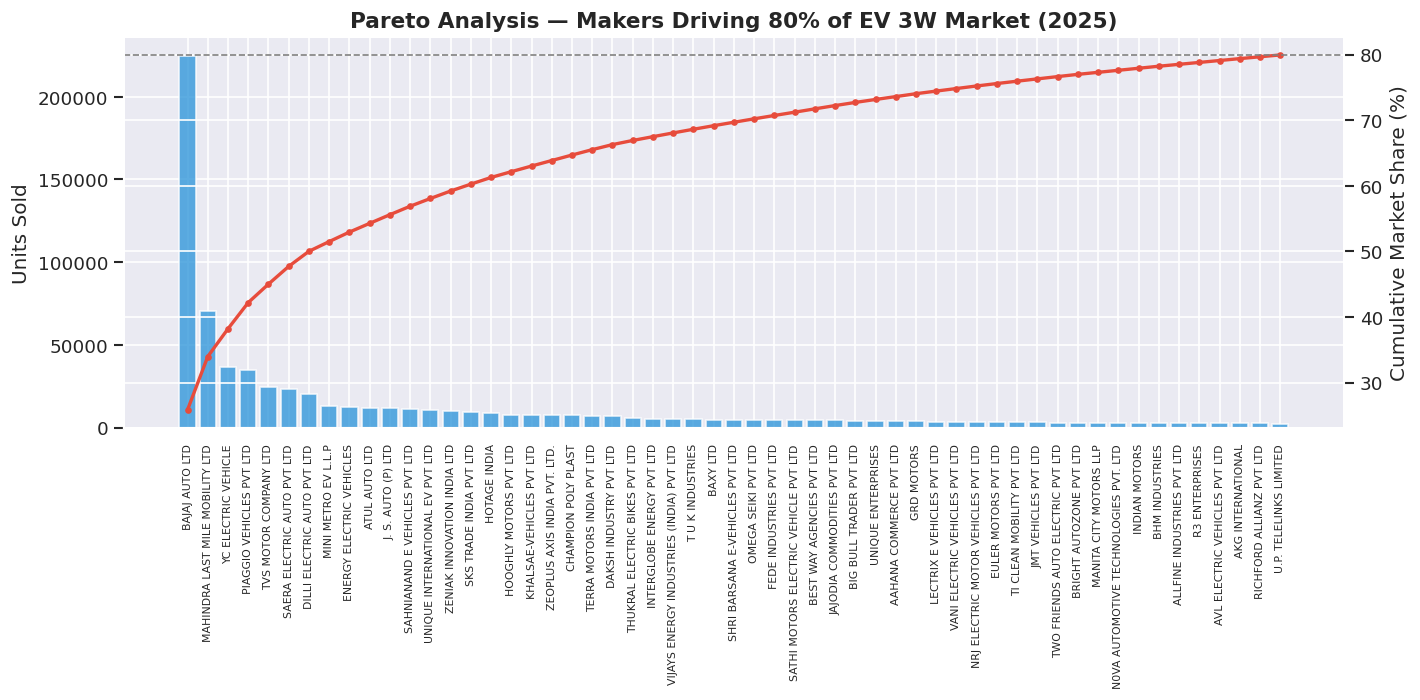

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.bar(range(len(top_80)), top_80['Registerations'], color='#3498db', alpha=0.8)
ax2.plot(range(len(top_80)), top_80['Cumulative_%'], color='#e74c3c', linewidth=2, marker='.')
ax2.axhline(80, color='grey', linestyle='--', linewidth=1)

ax1.set_xticks(range(len(top_80)))
ax1.set_xticklabels(top_80['Maker'], rotation=90, fontsize=6.5)
ax1.set_ylabel('Units Sold')
ax2.set_ylabel('Cumulative Market Share (%)')
ax1.set_title('Pareto Analysis — Makers Driving 80% of EV 3W Market (2025)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/dilli_ev_project/outputs/plot6_pareto.png')
plt.show()


## 9. Key Business Insights

| # | Insight | Implication for DEA |
|---|---------|---------------------|
| 1 | DEA holds **2.31% national market share** (20,065 units) | Strong base but significant room to grow |
| 2 | **Bajaj dominates** with 224,736 units — 11.2x DEA's volume | DEA's fight is for #2 position, not Bajaj's segment |
| 3 | **UP is DEA's strongest state** — highest registrations | Double down on UP distribution and service network |
| 4 | **Bihar and West Bengal** have large markets but low DEA share | High-opportunity expansion states |
| 5 | **Q4 (Oct–Dec) is peak season** — industry-wide surge | Ensure inventory and dealer readiness by September |
| 6 | Only **55 makers drive 80%** of all registrations | Market is moderately concentrated — top 10 matter most |
| 7 | DEA active in **all 11 states** but uneven performance | Focus resources on high-market states before expanding further |

---
*Analysis by Aarav | Data: VAHAN 2025 | Project: Dilli Electric Auto EV Intelligence Tool*
